# SDXL CollageNet

In [1]:
from __future__ import annotations

import importlib
import sys
from dataclasses import asdict, replace
from pathlib import Path

from IPython.display import display
from PIL import Image

ROOT = Path("/home/ubuntu/projects/collage-net")
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import patch_dictionary_core
import render_config
import render_runtime

importlib.reload(patch_dictionary_core)
importlib.reload(render_config)
importlib.reload(render_runtime)

from render_config import GenerationConfig, ModelConfig, ProjectionConfig
from render_runtime import (
    DEVICE,
    PATCH_BANK_DTYPE,
    PIPELINE_DTYPE,
    build_runtime_patch_bank,
    load_pipeline,
    render_one,
    set_seed,
)

print(f"DEVICE={DEVICE}")
print(f"PIPELINE_DTYPE={PIPELINE_DTYPE}")
print(f"PATCH_BANK_DTYPE={PATCH_BANK_DTYPE}")

DEVICE=cuda
PIPELINE_DTYPE=torch.float16
PATCH_BANK_DTYPE=torch.bfloat16


In [2]:
# Runtime helpers now come from `render_runtime.py`.
# Rerun the import cell above after editing project modules.

In [3]:
print(f"Loaded modules from {ROOT}")
print(f"patch_dictionary_core={patch_dictionary_core.__file__}")
print(f"render_config={render_config.__file__}")
print(f"render_runtime={render_runtime.__file__}")

Loaded modules from /home/ubuntu/projects/collage-net
patch_dictionary_core=/home/ubuntu/projects/collage-net/patch_dictionary_core.py
render_config=/home/ubuntu/projects/collage-net/render_config.py
render_runtime=/home/ubuntu/projects/collage-net/render_runtime.py


In [4]:
# Notebook goal: tweak LoRA, prompts, and projection parameters interactively.
# The core rendering logic lives in `render_runtime.py` and `patch_dictionary_core.py`.

In [5]:
model_cfg = ModelConfig(
    lora_repo="JoelSimon/joel",
    lora_weight_name="pytorch_lora_weights.safetensors",
    embedding_filename="joel_emb.safetensors",
    embedding_token=["<s0>", "<s1>"],
)

pipe = load_pipeline(model_cfg)

print(asdict(model_cfg))

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

{'model_id': 'stabilityai/stable-diffusion-xl-base-1.0', 'vae_id': 'madebyollin/sdxl-vae-fp16-fix', 'lora_repo': 'JoelSimon/joel', 'lora_weight_name': 'pytorch_lora_weights.safetensors', 'embedding_filename': 'joel_emb.safetensors', 'embedding_token': ['<s0>', '<s1>'], 'use_safetensors': True}


In [32]:
patch_cfg = ProjectionConfig(
    # latent_dir=ROOT / "watercolor-latents",
    latent_dir=ROOT / "gan-upscaled-latents",
    region_method="felzenszwalb",
    patch_size=1,
    do_rotated=True,
    total_patches=50000,
    projection_start_frac=0.6,
    projection_end_frac=1.0,
    alpha_start=0.0,
    alpha_end=0.10,
    region_candidate_count=128,
    region_min_area=1,
    region_max_area=1200,
    felzenszwalb_scale=2.0,
    felzenszwalb_sigma=3,
    felzenszwalb_min_size=12,
)

gen_cfg = GenerationConfig(
    prompt="a closeup portrait of <s0><s1> on a white background.",
    negative_prompt="blurry, low quality, deformed, extra limbs, text, watermark",
    height=1400-64,
    width=1400-64,
    num_inference_steps=30,
    guidance_scale=6.5,
    seed=1,
    output_stem="sdxl_patch_dictionary",
    pixel_render_scale=1,
)

set_seed(gen_cfg.seed)
assert patch_cfg.region_method in {"square", "threshold", "felzenszwalb"}
assert patch_cfg.threshold_connectivity in {4, 8}
assert (gen_cfg.width // 8) % patch_cfg.patch_size == 0
assert (gen_cfg.height // 8) % patch_cfg.patch_size == 0
assert gen_cfg.pixel_render_scale >= 1

print(asdict(patch_cfg))
print(asdict(gen_cfg))

{'latent_dir': PosixPath('/home/ubuntu/projects/collage-net/gan-upscaled-latents'), 'region_method': 'felzenszwalb', 'patch_size': 1, 'do_rotated': True, 'total_patches': 50000, 'top_k': 1, 'projection_start_frac': 0.6, 'projection_end_frac': 1.0, 'projection_every_n_steps': 1, 'alpha_start': 0.0, 'alpha_end': 0.1, 'dictionary_chunk_size': 8192, 'similarity_temperature': 0.1, 'preview_every_n_projections': 0, 'random_seed': 1234, 'region_candidate_count': 128, 'region_min_area': 1, 'region_max_area': 1200, 'region_max_bbox_h': 0, 'region_max_bbox_w': 0, 'debug_every_n_projections': 1, 'threshold_min_regions': 64, 'threshold_max_regions': 768, 'threshold_connectivity': 8, 'threshold_similarity_low': -0.25, 'threshold_similarity_high': 0.999, 'felzenszwalb_scale': 2.0, 'felzenszwalb_sigma': 3, 'felzenszwalb_min_size': 12}
{'prompt': 'a closeup portrait of <s0><s1> on a white background.', 'negative_prompt': 'blurry, low quality, deformed, extra limbs, text, watermark', 'height': 1336, 'w

In [33]:
patch_bank = build_runtime_patch_bank(patch_cfg)

print(f"region_method={patch_cfg.region_method}")
print(f"patch_bank.raw_patches.shape={tuple(patch_bank.raw_patches.shape)}")
print(f"patch_bank.raw_patches.dtype={patch_bank.raw_patches.dtype}")
print(f"patch_bank.normalized_patches.dtype={patch_bank.normalized_patches.dtype}")
print("patch counts by file:")
for name, count in patch_bank.source_counts.items():
    print(f"  {name}: {count}")

region_method=felzenszwalb
patch_bank.raw_patches.shape=(50000, 4)
patch_bank.raw_patches.dtype=torch.bfloat16
patch_bank.normalized_patches.dtype=torch.float32
patch counts by file:
  2d56007ac3154f88ada12343a4835ade.npz: 6250
  2d56007ac3154f88ada12343a4835ade_rot90.npz: 6250
  2d56007ac3154f88ada12343a4835ade_rot180.npz: 6250
  2d56007ac3154f88ada12343a4835ade_rot270.npz: 6250
  79d43f585ab740e791aa92f329eab4e5.npz: 6250
  79d43f585ab740e791aa92f329eab4e5_rot90.npz: 6250
  79d43f585ab740e791aa92f329eab4e5_rot180.npz: 6250
  79d43f585ab740e791aa92f329eab4e5_rot270.npz: 6250


  0%|          | 0/30 [00:00<?, ?it/s]

Saved final image to /home/ubuntu/projects/collage-net/outputs/sdxl_patch_dictionary/sdxl_patch_dictionary.png
Projection events: 12


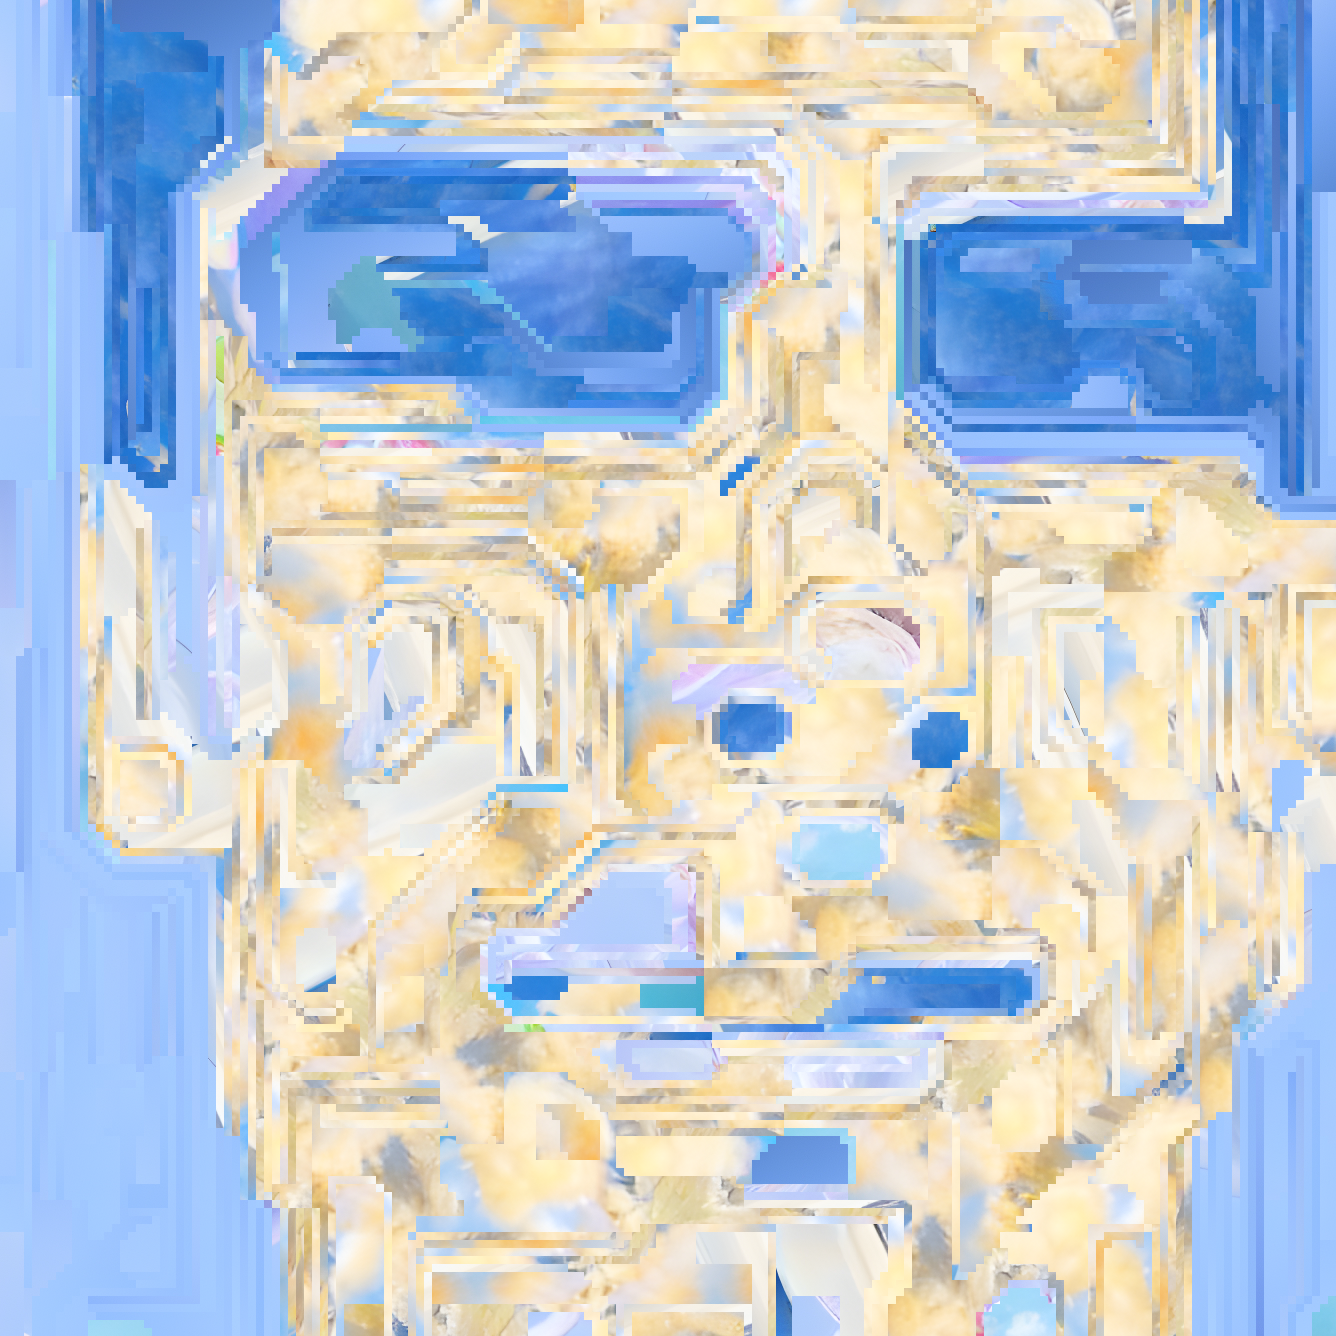

In [34]:
run_dir = OUTPUT_DIR / (gen_cfg.output_stem or "notebook_render")
run_dir.mkdir(parents=True, exist_ok=True)

run_result = render_one(
    pipe=pipe,
    gen_cfg=gen_cfg,
    patch_cfg=patch_cfg,
    patch_bank=patch_bank,
    output_dir=run_dir,
    final_filename=f"{gen_cfg.output_stem or 'render'}.png",
    save_auxiliary_outputs=True,
    save_displayed_image=True,
)

final_path = Path(run_result["final_path"])
print(f"Saved final image to {final_path}")
print(f"Projection events: {run_result['num_projection_events']}")
display(Image.open(final_path))

In [ ]:
num_seed_runs = 8
seed_offset = 0
seed_output_dir = OUTPUT_DIR / f"{gen_cfg.output_stem or 'notebook_render'}_seed_batch"
seed_output_dir.mkdir(parents=True, exist_ok=True)

seed_results = []
for seed in range(gen_cfg.seed + seed_offset, gen_cfg.seed + seed_offset + num_seed_runs):
    run_gen_cfg = replace(gen_cfg, seed=seed)
    output_name = f"seed_{seed:04d}.png"

    print(f"running seed={seed} -> {output_name}")
    run_result = render_one(
        pipe=pipe,
        gen_cfg=run_gen_cfg,
        patch_cfg=patch_cfg,
        patch_bank=patch_bank,
        output_dir=seed_output_dir,
        final_filename=output_name,
        save_auxiliary_outputs=False,
        save_displayed_image=True,
    )
    seed_results.append({"seed": seed, **run_result})

print(f"Saved {len(seed_results)} final images to {seed_output_dir}")
seed_results[:5]